<a href="https://colab.research.google.com/github/Rijwan94/DS_Pyhton_M2/blob/main/Applied_Statistics_Project_PBA_Rijwan_Shaikh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Purchase Behavior Analysis using Descriptive Statistics

- Rijwan Shaikh

##Problem Statement

🔍 **Problem Statement**:

Welcome to the Probability and Statistics project! 📊🔍 In this exciting journey, you'll get the chance to apply the concepts you've learned in probability theory and statistics to analyze a real-world dataset. This project is your opportunity to dive deep into the world of data analysis and gain practical experience with the tools and techniques you've been learning. 🚀

🎯 **Objective**:

Your mission is to analyze the provided dataset containing customer information and purchasing behavior to make informed decisions. Your goal is to identify patterns, trends, and correlations that will help your company optimize its marketing efforts and increase offer acceptance rates. 🎉

##About the Dataset



Here's the link to the [dataset](https://docs.google.com/spreadsheets/d/12ln9iTNcVNOMYi_AU-OczKpa_KIP8XyVbsjk81Na8Yk/edit?usp=sharing)


This data was gathered during last year's campaign.
Data description is as follows;

1. Response (target) - 1 if customer accepted the offer in the last campaign, 0 otherwise
1. ID - Unique ID of each customer
1. Year_Birth - Age of the customer
1. Complain - 1 if the customer complained in the last 2 years
1. Dt_Customer - date of customer's enrollment with the company
1. Education - customer's level of education
1. Marital - customer's marital status
1. Kidhome - number of small children in customer's household
1. Teenhome - number of teenagers in customer's household
1. Income - customer's yearly household income
1. MntFishProducts - the amount spent on fish products in the last 2 years
1. MntMeatProducts - the amount spent on meat products in the last 2 years
1. MntFruits - the amount spent on fruits products in the last 2 years
1. MntSweetProducts - amount spent on sweet products in the last 2 years
1. MntWines - the amount spent on wine products in the last 2 years
1. MntGoldProds - the amount spent on gold products in the last 2 years
1. NumDealsPurchases - number of purchases made with discount
1. NumCatalogPurchases - number of purchases made using catalog (buying goods to be shipped through the mail)
1. NumStorePurchases - number of purchases made directly in stores
1. NumWebPurchases - number of purchases made through the company's website
1. NumWebVisitsMonth - number of visits to company's website in the last month
1. Recency - number of days since the last purchase





##Task 1 - Basic CleanUp

- **Clean and preprocess the dataset (handling missing values, data types, etc.).**

- **Analyze the distribution of customer demographics (age, education, marital status) using descriptive statistics and visualizations.**



**Deliverables**:

- **Cleaned and Preprocessed Dataset**:

  Provide a detailed report on the steps taken to handle missing values, including imputation methods used if applicable.
  Document the process of ensuring consistent data types for each variable, addressing any inconsistencies.

- **Summary of Basic Statistics**:

  Present calculated statistics such as mean, median, variance, and standard deviation for each relevant numerical variable.
  Include a concise table or summary showcasing these measures for easy reference.

#Load Dataset

###Required Libraries

In [75]:
#Import Libraries
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
from scipy.stats import binom, norm
from scipy.stats import poisson
from scipy.stats import expon
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis, shapiro

Connect Drive

In [76]:
#Connect drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load CSV File / Dataset

In [77]:
#Load CSV File
PBA_df = pd.read_csv('/content/drive/MyDrive/Data Science/5. Applied Statistics/Mid Course/Superstore Marketing Data - Sheet1.csv', encoding='latin-1')


In [78]:
#First look of Dataframe PBA_df
PBA_df


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,########,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,########,0,6,...,11,0,34,2,3,1,2,7,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,########,99,372,...,47,48,78,2,5,2,11,4,0,0
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,3,8,16,1,1,0,3,8,0,0
2237,22,1976,Graduation,Divorced,46310.0,1,0,########,99,185,...,15,5,14,2,6,1,5,8,0,0
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,149,165,63,1,5,4,10,3,0,0


In [79]:
# Get the number of rows and columns
rows, cols = PBA_df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")


Number of rows: 2240
Number of columns: 22


In [80]:
#Summary of PBA_df

print(PBA_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [81]:
# Check for missing values
print(PBA_df.isnull().sum())


Id                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Response                0
Complain                0
dtype: int64


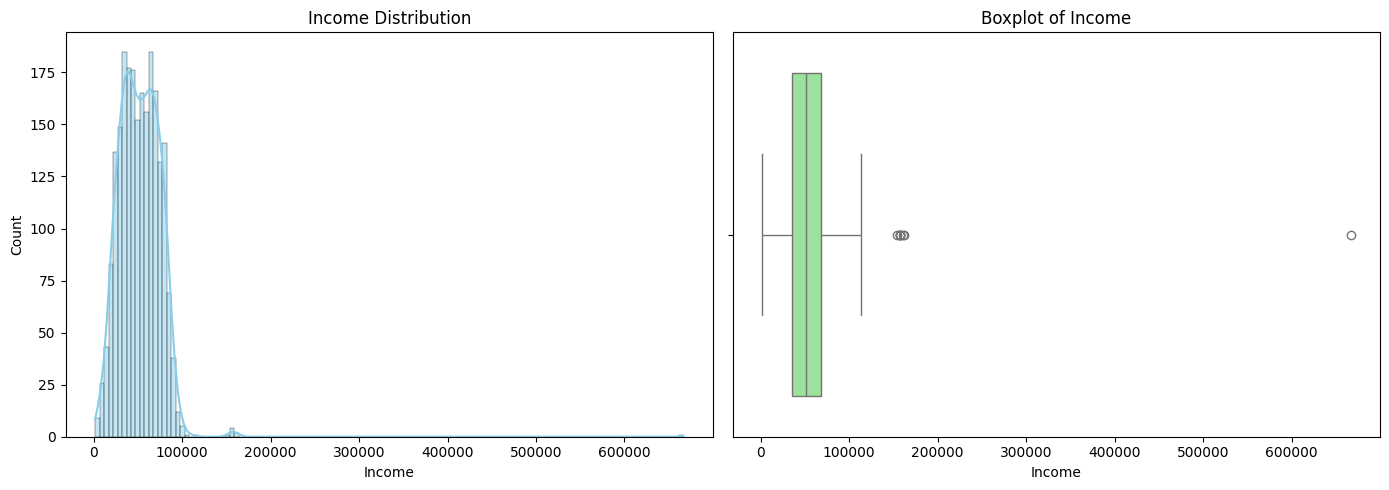

Mean Income: 52247.25
Median Income: 51381.5
Mode Income: 7500.0
Skewness: 6.76

✅ Based on the skewed distribution, MEDIAN is selected to impute missing values.

Missing values in 'Income' 24


In [82]:
# Analyze and Impute Income Column

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# 1. Visualize Income Distribution
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(PBA_df['Income'], kde=True, color='skyblue')
plt.title('Income Distribution')
plt.xlabel('Income')

plt.subplot(1, 2, 2)
sns.boxplot(x=PBA_df['Income'], color='lightgreen')
plt.title('Boxplot of Income')

plt.tight_layout()
plt.show()

# 2. Summary Statistics
income_mean = PBA_df['Income'].mean()
income_median = PBA_df['Income'].median()
income_mode = PBA_df['Income'].mode()[0]
income_skew = skew(PBA_df['Income'].dropna())

print("Mean Income:", round(income_mean, 2))
print("Median Income:", round(income_median, 2))
print("Mode Income:", income_mode)
print("Skewness:", round(income_skew, 2))

# 3. Based on analysis, MEDIAN is the best method
print("\n✅ Based on the skewed distribution, MEDIAN is selected to impute missing values.")

# 4. Confirm Imputation
print("\nMissing values in 'Income'", PBA_df['Income'].isnull().sum())


In [83]:
PBA_df['Income'] = PBA_df['Income'].fillna(income_median)

In [84]:
# 4. Confirm Imputation
print("\nMissing values in 'Income' after imputation:", PBA_df['Income'].isnull().sum())


Missing values in 'Income' after imputation: 0


In [85]:
#Add new 'Age' Column to the df for better understanding
#Calculate today's date
today = datetime.today().year

# Function to calculate age
def calculate_age(year_birth):
    return today - year_birth

# Apply the function to create the 'Age' column
PBA_df['Age'] = PBA_df['Year_Birth'].apply(calculate_age)


In [86]:
# Display 'Year_Birth' and added column 'Age'
print(PBA_df[['Year_Birth', 'Age']])

      Year_Birth  Age
0           1970   55
1           1961   64
2           1958   67
3           1967   58
4           1989   36
...          ...  ...
2235        1976   49
2236        1977   48
2237        1976   49
2238        1978   47
2239        1969   56

[2240 rows x 2 columns]


In [87]:
# Convert the 'Dt_Customer' column to datetime
PBA_df['Dt_Customer'] = pd.to_datetime(PBA_df['Dt_Customer'], errors='coerce')

In [88]:
missing_values = PBA_df['Dt_Customer'].isnull().sum()
print(missing_values)

916


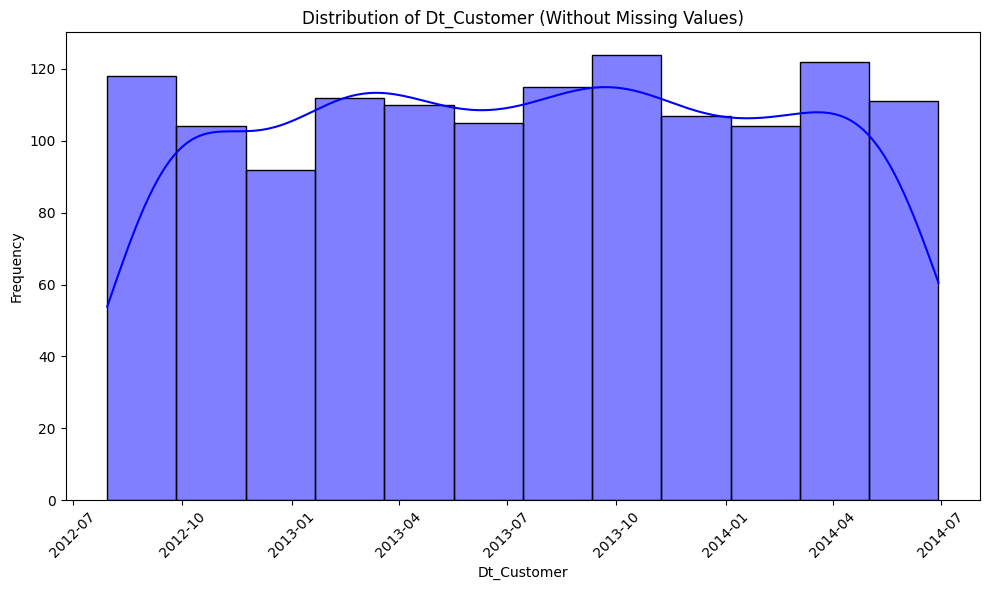

### 🗂 Column Analyzed: 'Dt_Customer'

- 📅 Most Frequent Date (Mode): 2012-08-31
- 🔢 Occurrences of Mode: 12
- 📊 Percentage of Mode in Total Non-Null Rows: 0.91%
- 📈 Skewness of Data: -0.01

#### ✅ Conclusion:
- The data is **relatively balanced**.
- There is **no clear skew or dominant mode**.
### 🔧 Recommended Imputation Method:
👉 Use the **median date** → 2013-07-21 for imputing missing values in 'Dt_Customer'.


In [90]:
# Column to analyze for Method to be used for Imputation for Dt_Customer
date_column = 'Dt_Customer'

# Step 1: Check for skewness
skewness = PBA_df[date_column].dropna().apply(lambda x: x.timestamp()).skew()

# Step 2: Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(PBA_df[date_column].dropna(), kde=True, color='blue')
plt.title(f"Distribution of {date_column} (Without Missing Values)")
plt.xlabel(date_column)
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 3: Calculate mode, count, and percentage
mode_value = PBA_df[date_column].mode()[0]
mode_count = PBA_df[date_column].value_counts()[mode_value]
total_count = PBA_df[date_column].notna().sum()
mode_percentage = (mode_count / total_count) * 100
median_value = PBA_df[date_column].median()

# Step 4: Final report with recommendation
print("### 🗂 Column Analyzed: 'Dt_Customer'\n")
print(f"- 📅 Most Frequent Date (Mode): {mode_value.date()}")
print(f"- 🔢 Occurrences of Mode: {mode_count}")
print(f"- 📊 Percentage of Mode in Total Non-Null Rows: {mode_percentage:.2f}%")
print(f"- 📈 Skewness of Data: {skewness:.2f}\n")

print("#### ✅ Conclusion:")

if abs(skewness) > 0.5:
    print("- The data is **skewed**.")
    print("- The mode appears in less than 10% of the data and does not dominate.")
    print("### 🔧 Recommended Imputation Method:")
    print(f"👉 Use the **median date** → {median_value.date()} for imputing missing values in 'Dt_Customer'.")
elif mode_percentage > 10:
    print("- The data has a **dominant date value**.")
    print(f"### 🔧 Recommended Imputation Method:")
    print(f"👉 Use the **mode date** → {mode_value.date()} for imputing missing values in 'Dt_Customer'.")
else:
    print("- The data is **relatively balanced**.")
    print("- There is **no clear skew or dominant mode**.")
    print("### 🔧 Recommended Imputation Method:")
    print(f"👉 Use the **median date** → {median_value.date()} for imputing missing values in 'Dt_Customer'.")


In [91]:
# Step 1: Calculate the median date
median_date = PBA_df['Dt_Customer'].median()

# Step 2: Impute missing values with the median date
PBA_df['Dt_Customer'] = PBA_df['Dt_Customer'].fillna(median_date)

# Step 3: Optional - Confirm imputation
print(f"✅ Missing values after imputation: {PBA_df['Dt_Customer'].isnull().sum()}")
print(f"🕓 Median date used for imputation: {median_date.date()}")


✅ Missing values after imputation: 0
🕓 Median date used for imputation: 2013-07-21
